# 01b L1B Sweep Tx/Rx Matrix

Purpose:
- read one specified CASALS L1B H5 file,
- extract one specified `sweep` using explicit `sweep_num` and `track_num`,
- assemble the 256-track transmit and receive waveforms into two matrices.

Notes:
- this notebook reads and organizes waveform matrices,
- the Rx plot includes a `refh` overlay defined here as the max-amplitude Rx bin per track,
- missing tracks are filled with `NaN` rows.

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Top-level parameters.
H5_PATH = Path('../casals_h5_downloads/casals_l1b_20241118T171757_001_02.h5')
SWEEP_IDX = 5000
# Amplitude display range for the Rx heatmaps.
# Keep both as None for automatic zero-centered scaling.
# Example: AMPLITUDE_VMIN = -2000; AMPLITUDE_VMAX = 4000
AMPLITUDE_VMIN = -1000
AMPLITUDE_VMAX = 4000

assert H5_PATH.exists(), H5_PATH

In [2]:
def waveform_record_axis(ds, n_records):
    if ds.ndim != 2:
        raise ValueError(f'{ds.name} must be 2D, got shape={ds.shape}')
    if ds.shape[0] == n_records:
        return 0, int(ds.shape[1])
    if ds.shape[1] == n_records:
        return 1, int(ds.shape[0])
    raise ValueError(
        f'{ds.name} shape {ds.shape} does not match n_records={n_records} on either axis.'
    )


def read_waveform_rows(ds, record_axis, indices):
    order = np.argsort(indices)
    indices_sorted = np.asarray(indices[order], dtype=np.int64)
    if record_axis == 0:
        rows_sorted = np.asarray(ds[indices_sorted, :], dtype=np.float32)
    else:
        rows_sorted = np.asarray(ds[:, indices_sorted].T, dtype=np.float32)
    rows = np.empty_like(rows_sorted)
    rows[order] = rows_sorted
    return rows


In [3]:
with h5py.File(H5_PATH, 'r') as h5:
    sweep_num = np.asarray(h5['sweep_num'][:], dtype=np.int64).reshape(-1)
    track_num = np.asarray(h5['track_num'][:], dtype=np.int64).reshape(-1)
    tx_ds = h5['tx_waveform']
    rx_ds = h5['rx_waveform']

    if sweep_num.size != track_num.size:
        raise ValueError(f'sweep_num and track_num sizes differ: {sweep_num.size} vs {track_num.size}')
    if sweep_num.size == 0:
        raise ValueError('No pulse records found.')
    if SWEEP_IDX < 0:
        raise ValueError(f'SWEEP_IDX must be >= 0, got {SWEEP_IDX}')

    n_records = int(sweep_num.size)
    n_sweeps = int(np.nanmax(sweep_num)) + 1
    if SWEEP_IDX >= n_sweeps:
        raise ValueError(f'SWEEP_IDX={SWEEP_IDX} is out of range for n_sweeps={n_sweeps}')

    tx_record_axis, n_tx_bins = waveform_record_axis(tx_ds, n_records)
    rx_record_axis, n_rx_bins = waveform_record_axis(rx_ds, n_records)

    mask = sweep_num == int(SWEEP_IDX)
    sweep_tracks = track_num[mask]
    sweep_record_indices = np.flatnonzero(mask)

    unique_tracks, counts = np.unique(sweep_tracks, return_counts=True)
    duplicate_tracks = unique_tracks[counts > 1]
    if duplicate_tracks.size:
        raise ValueError(
            f'Selected sweep has duplicate track entries: {duplicate_tracks[:10].tolist()}'
        )

    track_to_record = {int(track): int(record) for track, record in zip(sweep_tracks, sweep_record_indices)}
    valid_tracks = sorted(t for t in track_to_record if 0 <= t < 256)
    valid_record_indices = np.asarray([track_to_record[t] for t in valid_tracks], dtype=np.int64)

    tx_matrix = np.full((256, n_tx_bins), np.nan, dtype=np.float32)
    rx_matrix = np.full((256, n_rx_bins), np.nan, dtype=np.float32)

    if valid_tracks:
        tx_matrix[np.asarray(valid_tracks, dtype=np.int64)] = read_waveform_rows(tx_ds, tx_record_axis, valid_record_indices)
        rx_matrix[np.asarray(valid_tracks, dtype=np.int64)] = read_waveform_rows(rx_ds, rx_record_axis, valid_record_indices)

print('H5 path:', H5_PATH.resolve())
print('SWEEP_IDX:', SWEEP_IDX)
print('tx_waveform shape:', tx_ds.shape)
print('rx_waveform shape:', rx_ds.shape)
print('tracks found in selected sweep:', len(valid_tracks))
print('tx_matrix shape:', tx_matrix.shape)
print('rx_matrix shape:', rx_matrix.shape)


H5 path: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5
SWEEP_IDX: 5000
tx_waveform shape: (3604480, 80)
rx_waveform shape: (3604480, 2728)
tracks found in selected sweep: 256
tx_matrix shape: (256, 80)
rx_matrix shape: (256, 2728)


refh markers plotted: 256
amplitude display range: -1000.0 4000.0
amplitude display center: 0.0


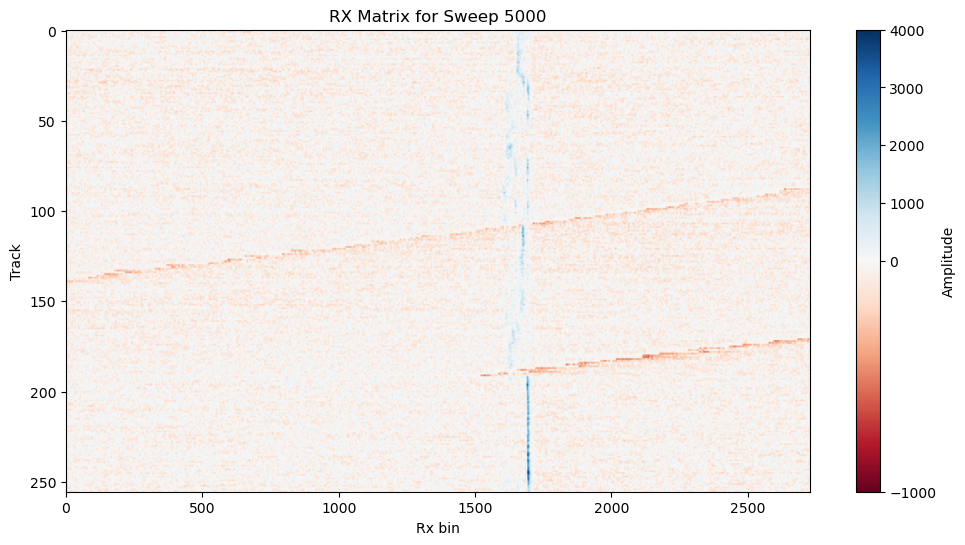

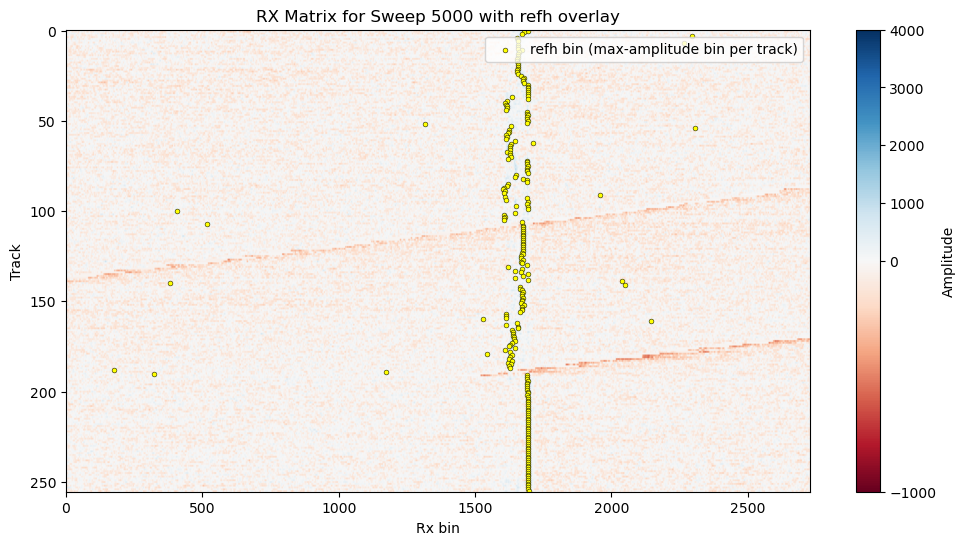

In [4]:
from matplotlib.colors import CenteredNorm, TwoSlopeNorm

finite_row = np.isfinite(rx_matrix).any(axis=1)
safe_rx = np.where(np.isfinite(rx_matrix), rx_matrix, -np.inf)
refh_bin_by_track = np.full(rx_matrix.shape[0], np.nan, dtype=np.float32)
refh_bin_by_track[finite_row] = np.argmax(safe_rx[finite_row], axis=1).astype(np.float32)
refh_tracks = np.flatnonzero(finite_row)

finite_vals = rx_matrix[np.isfinite(rx_matrix)]
auto_vmin = float(np.nanmin(finite_vals))
auto_vmax = float(np.nanmax(finite_vals))

if AMPLITUDE_VMIN is None and AMPLITUDE_VMAX is None:
    amplitude_norm = CenteredNorm(vcenter=0)
else:
    display_vmin = auto_vmin if AMPLITUDE_VMIN is None else float(AMPLITUDE_VMIN)
    display_vmax = auto_vmax if AMPLITUDE_VMAX is None else float(AMPLITUDE_VMAX)
    if display_vmin >= display_vmax:
        raise ValueError(
            f'AMPLITUDE_VMIN must be smaller than AMPLITUDE_VMAX, got {display_vmin} >= {display_vmax}'
        )
    if display_vmin > 0:
        display_vmin = 0.0
    if display_vmax < 0:
        display_vmax = 0.0
    amplitude_norm = TwoSlopeNorm(vmin=display_vmin, vcenter=0.0, vmax=display_vmax)

print('refh markers plotted:', int(refh_tracks.size))
print('amplitude display range:', amplitude_norm.vmin, amplitude_norm.vmax)
print('amplitude display center:', amplitude_norm.vcenter)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(rx_matrix, cmap='RdBu', aspect='auto', norm=amplitude_norm)
fig.colorbar(im, ax=ax, label='Amplitude')
ax.set_title(f'RX Matrix for Sweep {SWEEP_IDX}')
ax.set_xlabel('Rx bin')
ax.set_ylabel('Track')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(rx_matrix, cmap='RdBu', aspect='auto', norm=amplitude_norm)
overlay = ax.scatter(
    refh_bin_by_track[finite_row],
    refh_tracks,
    s=12,
    c='yellow',
    edgecolors='black',
    linewidths=0.35,
    label='refh bin (max-amplitude bin per track)',
)
fig.colorbar(im, ax=ax, label='Amplitude')
ax.set_title(f'RX Matrix for Sweep {SWEEP_IDX} with refh overlay')
ax.set_xlabel('Rx bin')
ax.set_ylabel('Track')
ax.legend(handles=[overlay], loc='upper right')

plt.show()

In [5]:
import plotly.graph_objects as go

# Light downsampling keeps the interactive surface responsive in notebook view.
RX_3D_BIN_STRIDE = 4
RX_3D_TRACK_STRIDE = 1

rx_matrix_3d = rx_matrix[::RX_3D_TRACK_STRIDE, ::RX_3D_BIN_STRIDE]
track_axis_3d = np.arange(0, rx_matrix.shape[0], RX_3D_TRACK_STRIDE, dtype=np.int32)
rx_bin_axis_3d = np.arange(0, rx_matrix.shape[1], RX_3D_BIN_STRIDE, dtype=np.int32)
rx_bin_grid_3d, track_grid_3d = np.meshgrid(rx_bin_axis_3d, track_axis_3d)

print('3D surface shape:', rx_matrix_3d.shape)
print('3D bin stride:', RX_3D_BIN_STRIDE)
print('3D track stride:', RX_3D_TRACK_STRIDE)

fig = go.Figure()
fig.add_surface(
    x=rx_bin_grid_3d,
    y=track_grid_3d,
    z=rx_matrix_3d,
    colorscale='RdBu',
    cmin=float(amplitude_norm.vmin),
    cmax=float(amplitude_norm.vmax),
    cmid=0.0,
    colorbar=dict(title='Amplitude'),
    hovertemplate='Track=%{y}<br>Rx bin=%{x}<br>Amplitude=%{z}<extra></extra>',
)
fig.update_layout(
    title=f'Interactive 3D RX surface for sweep {SWEEP_IDX}',
    width=1100,
    height=750,
    scene=dict(
        xaxis_title='Rx bin',
        yaxis_title='Track',
        zaxis_title='Amplitude',
        camera=dict(eye=dict(x=1.6, y=1.5, z=0.9)),
    ),
)
fig.show()


3D surface shape: (256, 682)
3D bin stride: 4
3D track stride: 1
